# Pyrace-v1 vs Pyrace-v3 comparison on models_DQN_v02

This notebook compares the saved DQN v02 checkpoints for:

- models/Pyrace-v1/models_DQN_v02
- models/Pyrace-v3/models_DQN_v02

It includes:

1) Reward curve images saved during training (rewards_*.png)
2) Greedy checkpoint evaluation using evaluate_dqn_checkpoints.evaluate_checkpoint()

In [ ]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Headless-friendly defaults (helps on macOS / CI)
os.environ.setdefault('SDL_VIDEODRIVER', 'dummy')

# Assignment requirement: run cleanly (suppress known non-actionable warnings)
warnings.filterwarnings(
    'ignore',
    message=r'.*The environment Pyrace-v\d is out of date.*',
    category=DeprecationWarning,
)

REPO_ROOT = Path('.').resolve()
RUN_DIR_V1 = REPO_ROOT / 'models' / 'Pyrace-v1' / 'models_DQN_v02'
RUN_DIR_V3 = REPO_ROOT / 'models' / 'Pyrace-v3' / 'models_DQN_v02'

print('v1 exists:', RUN_DIR_V1.exists())
print('v3 exists:', RUN_DIR_V3.exists())

In [5]:
def _maybe_show_side_by_side(img_left: Path, img_right: Path, *, title_left: str, title_right: str, suptitle: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(suptitle)

    for ax, path, title in [(axes[0], img_left, title_left), (axes[1], img_right, title_right)]:
        ax.set_title(title)
        ax.axis('off')
        if not path.exists():
            ax.text(0.5, 0.5, f'MISSING\n{path}', ha='center', va='center')
            continue
        img = plt.imread(str(path))
        ax.imshow(img)

    plt.tight_layout()
    plt.show()


def rewards_png(run_dir: Path, ckpt: str) -> Path:
    label = 'final' if ckpt == 'final' else str(int(ckpt))
    return run_dir / f'rewards_{label}.png'


def model_pt(run_dir: Path, ckpt: str) -> Path:
    return run_dir / ('model_final.pt' if ckpt == 'final' else f'model_{int(ckpt)}.pt')

## 1) Reward curves (saved during training)

Edit `PLOT_CHECKPOINTS` if you want more/less.

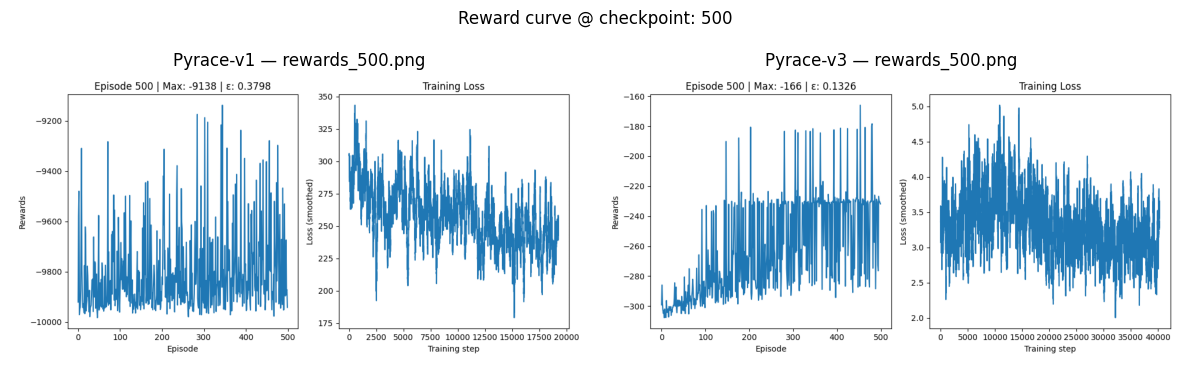

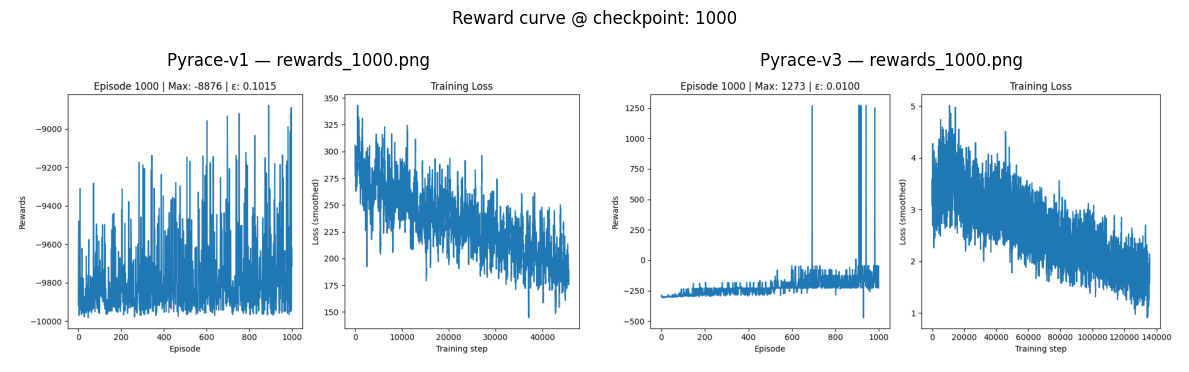

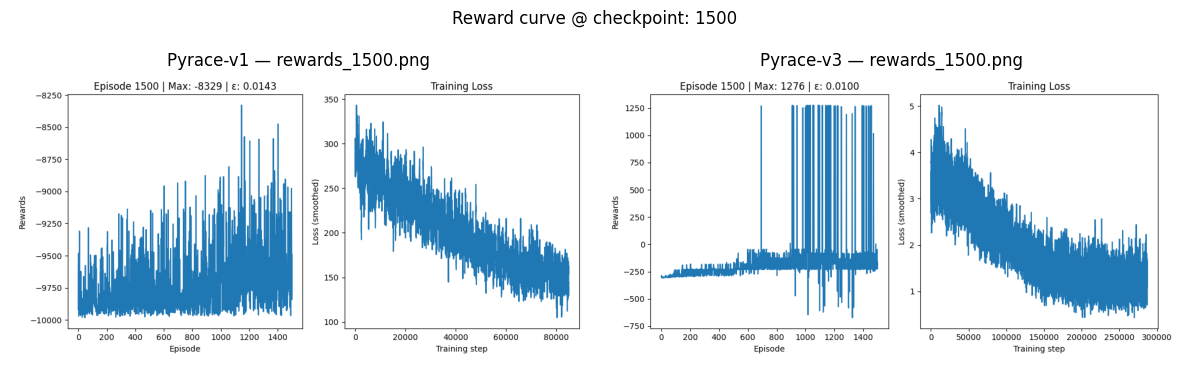

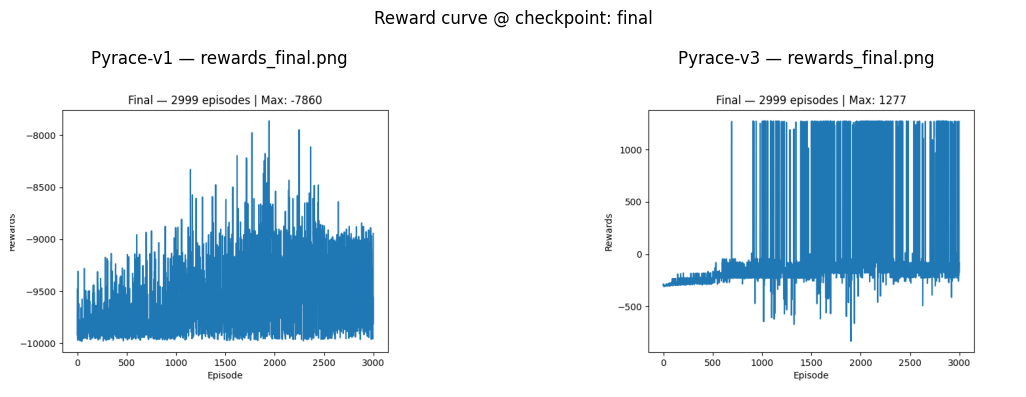

In [16]:
PLOT_CHECKPOINTS = ['500', '1000', '1500', 'final']

for ckpt in PLOT_CHECKPOINTS:
    _maybe_show_side_by_side(
        rewards_png(RUN_DIR_V1, ckpt),
        rewards_png(RUN_DIR_V3, ckpt),
        title_left=f'Pyrace-v1 — rewards_{ckpt}.png',
        title_right=f'Pyrace-v3 — rewards_{ckpt}.png',
        suptitle=f'Reward curve @ checkpoint: {ckpt}',
    )

Seeing this reward curve, v3 seems better at a glance. However, v1 vs v3 reward*values are not directly comparable due to different reward functions.

In the code:
- v1 (sparse): goal reward is +10000, crash reward is roughly -10000 + distance.
- v3 haped): small per-step penalty (~-0.1) plus speed bonus, progress shaping toward checkpoints, goal reward is +1000, crash is strongly negative (~-300 + 10*checkpoint).

So a higher reward curve in v3 does not necessarily mean better driving versus v1.

## 2) Greedy checkpoint evaluation

This runs each saved checkpoint with a greedy policy and reports:
- goal / crash / timeout rates
- mean max checkpoint reached and mean max distance


In [13]:
from pathlib import Path

from evaluate_dqn_checkpoints import evaluate_checkpoint

CHECKPOINTS = ['500', '1000', '1500', '2000', '2500', 'final']

# DQN_v02 uses a 5→128→128→3 MLP + normalized inputs
EVAL_CFG = dict(
    hidden_layers=[128, 128],
    normalize_obs=True,
    episodes=20,
    max_steps=2000,
    seed=0,
 )

def eval_run(env_id: str, run_dir: Path, checkpoints: list[str]):
    rows = []
    for ckpt in checkpoints:
        ckpt_path = model_pt(run_dir, ckpt)
        if not ckpt_path.exists():
            rows.append({'env_id': env_id, 'checkpoint': ckpt, 'status': 'MISSING'})
            continue
        res = evaluate_checkpoint(env_id, str(ckpt_path), **EVAL_CFG)
        rows.append({
            'env_id': env_id,
            'checkpoint': ckpt,
            'status': 'OK',
            'mean_return': res.mean_return,
            'mean_steps': res.mean_steps,
            'goal_rate': res.goal_rate,
            'crash_rate': res.crash_rate,
            'timeout_rate': res.timeout_rate,
            'mean_max_check': res.mean_max_check,
            'mean_max_dist': res.mean_max_dist,
        })
    return rows

rows = []
rows += eval_run('Pyrace-v1', RUN_DIR_V1, CHECKPOINTS)
rows += eval_run('Pyrace-v3', RUN_DIR_V3, CHECKPOINTS)

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    df_ok = df[df['status'] == 'OK'].copy()
    df_ok['checkpoint_sort'] = df_ok['checkpoint'].apply(lambda x: 10**9 if x == 'final' else int(x))
    df_ok = df_ok.sort_values(['env_id', 'checkpoint_sort']).drop(columns=['checkpoint_sort'])
    display(df_ok)
except Exception as e:
    print('Could not use pandas display:', e)
    for r in rows:
        print(r)

/Users/onosaeka/Uni/BCSAI/3-2/RL/RL-Car-Driving/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Pyrace-v1 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


init
init
init
init
init
init


/Users/onosaeka/Uni/BCSAI/3-2/RL/RL-Car-Driving/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Pyrace-v3 is out of date. You should consider upgrading to version `v4`.
  logger.deprecation(


init
init
init
init
init
init


,env_id,checkpoint,status,mean_return,mean_steps,goal_rate,crash_rate,timeout_rate,mean_max_check,mean_max_dist
0,Pyrace-v1,500,OK,-8970.500000,113.0,0.0,1.0,0.0,1.0,1019.5
1,Pyrace-v1,1000,OK,-9961.500000,11.0,0.0,1.0,0.0,0.0,30.5
2,Pyrace-v1,1500,OK,-9763.000000,237.0,0.0,1.0,0.0,0.0,236.0
3,Pyrace-v1,2000,OK,-8965.500000,114.0,0.0,1.0,0.0,1.0,1024.5
4,Pyrace-v1,2500,OK,-9859.000000,23.0,0.0,1.0,0.0,0.0,131.0
5,Pyrace-v1,final,OK,-9914.000000,29.0,0.0,1.0,0.0,0.0,80.5
6,Pyrace-v3,500,OK,-229.421696,86.0,0.0,1.0,0.0,1.0,820.0
7,Pyrace-v3,1000,OK,-199.840047,2000.0,0.0,0.0,1.0,0.0,3.0
8,Pyrace-v3,1500,OK,-199.840047,2000.0,0.0,0.0,1.0,0.0,3.0
9,Pyrace-v3,2000,OK,-199.920023,2000.0,0.0,0.0,1.0,0.0,1.5


In these runs, neither environment reaches the goal (goal_rate = 0 in 20 greedy evaluation episodes per checkpoint).

v1 sometimes reaches checkpoint 1 with mean_max_dist ≈ 1000 (e.g., at 500 and 2000). On the other hand, v3 times out frequently at some checkpoints, which suggests the policy can get stuck/spin rather than making forward progress. For driving performance, the progress metrics (mean_max_check, mean_max_dist` are the most comparable between v1 and v3.